# Training the visual search model, start to finish

This notebook walks through the final model from this repository —
the one that predicts **where the eyes go first** during visual
search — and trains it from scratch **on the actual data**: 114,232
first eye movements from 333 people across 11 published experiments.

**Scope: the first saccade of each trial.** The eyes start at the
screen center, the display appears, and the model predicts where they
go. Later saccades bring in extra machinery (inhibition of return,
changing vantage points) and are out of scope here.

**Input and output.** For each trial the model receives: a picture of
the display (pixels), the goal (the color and shape to look for), and
the history of previous trials. It returns **a probability for every
item on the screen**. One predicted saccade is one random draw.

**Before running:** build the dataset once (needs the public data
from https://osf.io/q27ph/):

    python pool_data.py --data_dir ".../Data Files" --out_dir dataset
    python build_contexts.py

Needs `numpy`, `pandas`, `matplotlib`, `torch`. Training takes about
ten minutes on a laptop.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from front_end import render, shape_for, item_positions, IMG
from build_contexts import (opponency_contrast, shape_match_map,
                            template_axis, wedge_profiles, NBINS, MAXR)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

radii_np = np.linspace(0.09, MAXR, NBINS)   # distance bins along each ray
pos, _ = item_positions(6)                  # the six item slots (a ring)

## 1. Model structure

The whole model is one equation. For each item *i*:

    priority(i) = window(i) x [ g_T * relu(targetColor(i))
                                - g_D * relu(distractorColor(i))
                                + g_F * shape(i)
                                + beta_T * h_T(i) + beta_D * h_D(i) ]

    P(first saccade -> i) = softmax over the items on the screen

Three sources are written into one **goal-modified salience map**:

- **color evidence**, split into two RECTIFIED channels: a
  target-color channel (relu keeps only where the display matches
  the target color; gain `g_T` = pure enhancement) and a
  distractor-color channel (only where it matches the distractor
  color; gain `g_D` = pure suppression);
- **shape evidence** — how well each location matches the searched
  shape (gain `g_F`);
- **location-based selection history** — a memory of where targets
  (`h_T`, gain `beta_T`) and distractors (`h_D`, gain `beta_D`) have
  appeared on previous trials.

An **attention window** centered on the eyes (parameters `k`, `r0`)
gates the whole map, and a softmax turns the gated map into choice
probabilities. Nine numbers are learned from data:
`g_T, g_D, g_F, k, r0, beta_T, beta_D, eta_T, eta_D`
(the two `eta`s are the memory update speeds, introduced in §5).

One honest note: from central fixation all items on the ring are
equally far away, so within this model's scope the window is flat
across items — it acts as a shared gain, doing no selective work. It
stays in the equation because it is theoretically defined (an
ego-anchored attention window), not because first-saccade data
constrain its shape.

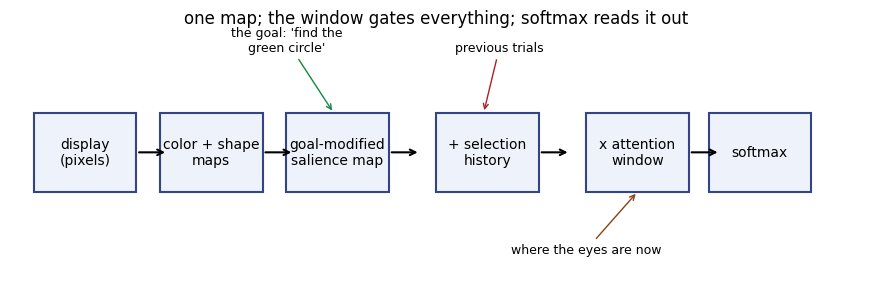

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.03, "display\n(pixels)"),
         (0.19, "color + shape\nmaps"),
         (0.35, "goal-modified\nsalience map"),
         (0.54, "+ selection\nhistory"),
         (0.73, "x attention\nwindow"),
         (0.885, "softmax")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.13, 0.32, fc="#eef2fa",
                               ec="#334488", lw=1.5))
    ax.text(x + 0.065, 0.51, label, ha="center", va="center", fontsize=10)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.17, 0.51), xytext=(x + 0.13, 0.51),
                arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'find the\ngreen circle'", xy=(0.41, 0.67),
            xytext=(0.35, 0.92), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previous trials", xy=(0.60, 0.67), xytext=(0.62, 0.92),
            ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.annotate("where the eyes are now", xy=(0.795, 0.35),
            xytext=(0.73, 0.10), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#884411"))
ax.set_xlim(0, 1.08); ax.set_ylim(0, 1); ax.axis("off")
plt.title("one map; the window gates everything; softmax reads it out")
plt.show()

## 2. The displays: one example per study

The dataset pools 11 experiments. Every subject searched one fixed
shape all session, so displays are reconstructed in canonical form —
a CIRCLE target among heterogeneous other shapes, green target color,
red singleton (each study's own color pair is shown here for
flavor). The target is defined by its shape and never "pops out" as
the odd one; the color singleton does. (Needs
`dataset/saccades_ctx.csv` from the build steps; Hamblin-Frohman
ships no color labels, so it falls back to green/red.)

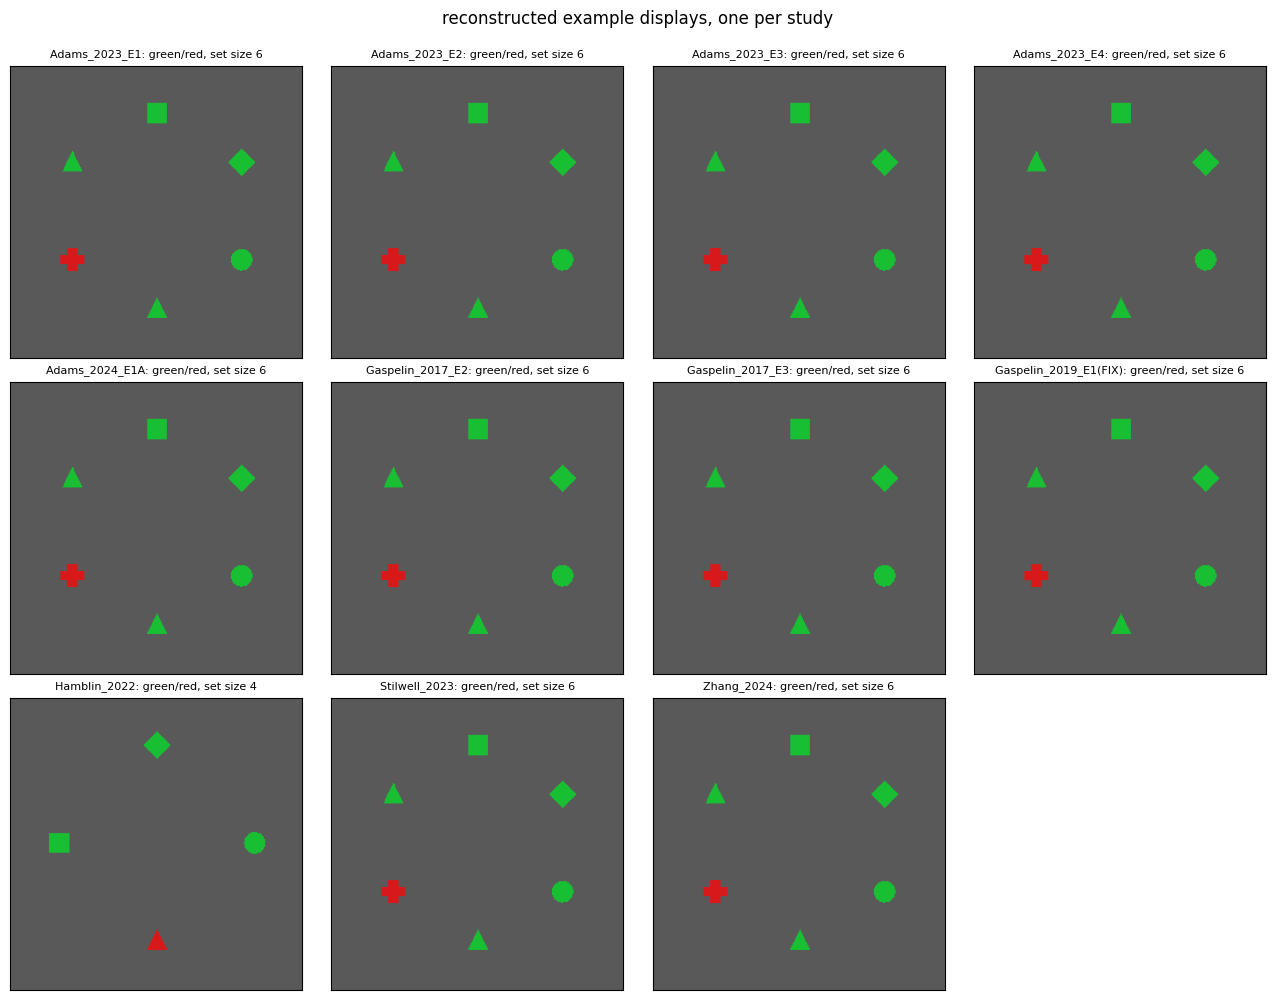

In [3]:
gal = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False,
                  usecols=["study", "setsize", "targCol", "singCol"])
gal = gal[gal.singCol != "none"]

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, (study, sub) in zip(axes.flat, gal.groupby("study")):
    setsize = int(sub.setsize.mode()[0])
    tc, sc = sub[["targCol", "singCol"]].mode().iloc[0]
    ipos, _ = item_positions(setsize)
    tg, sg = 2, (2 + setsize // 2) % setsize + 1   # target & singleton slots
    items = [dict(x=ipos[j][0], y=ipos[j][1],
                  color=sc if (j + 1) == sg else tc,
                  shape=shape_for(j + 1, tg)) for j in range(setsize)]
    ax.imshow(render(items), origin="lower")
    ax.set_title(f"{study}: {tc}/{sc}, set size {setsize}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[gal.study.nunique():]:
    ax.axis("off")
plt.suptitle("reconstructed example displays, one per study", y=0.995)
plt.tight_layout()
plt.show()

## 3. From one display to the goal-modified salience map

We take one canonical display and follow it through the perception
stage, one parameter at a time.

**The color pathway.** The raw color contrast map (how much each
pixel's color stands out from the background, signed along the
red-green axis) is split into two RECTIFIED channels:

- `relu(D_T)` — the target-color channel: nonzero only where the
  display matches the target color (the green items). Its gain is
  `g_T`: **pure enhancement**. Higher `g_T` lifts the green items and
  touches nothing else — after rectification the red item's value
  in this channel is exactly zero;
- `relu(D_dist)` — the distractor-color channel: nonzero only where
  the display matches the distractor color (the red singleton). Its
  gain is `g_D`, entering with a minus sign: **pure suppression**.
  Higher `g_D` digs the singleton's hole deeper and touches nothing
  else. (`b = 0` would mean no down-weighting at all; `b < 0` would
  make the distractor color attract — capture. The data choose.)

Because each gain now acts on its own one-sided channel, `g_T` and
`g_D` have separate, readable meanings — this is why the one-sided
form is the model of record (a fully linear form fits the same to
within noise).

The combined color evidence is their sum:

    g_T * relu(D_T)  -  g_D * relu(D_dist)

The gains below are placeholders; §7 learns them from the eye
movements. Every map has its own color bar, and each panel is
scaled to its own maximum — so turning a knob changes only its own
panel, and magnitudes are compared by reading the color bars, not
the color intensity.

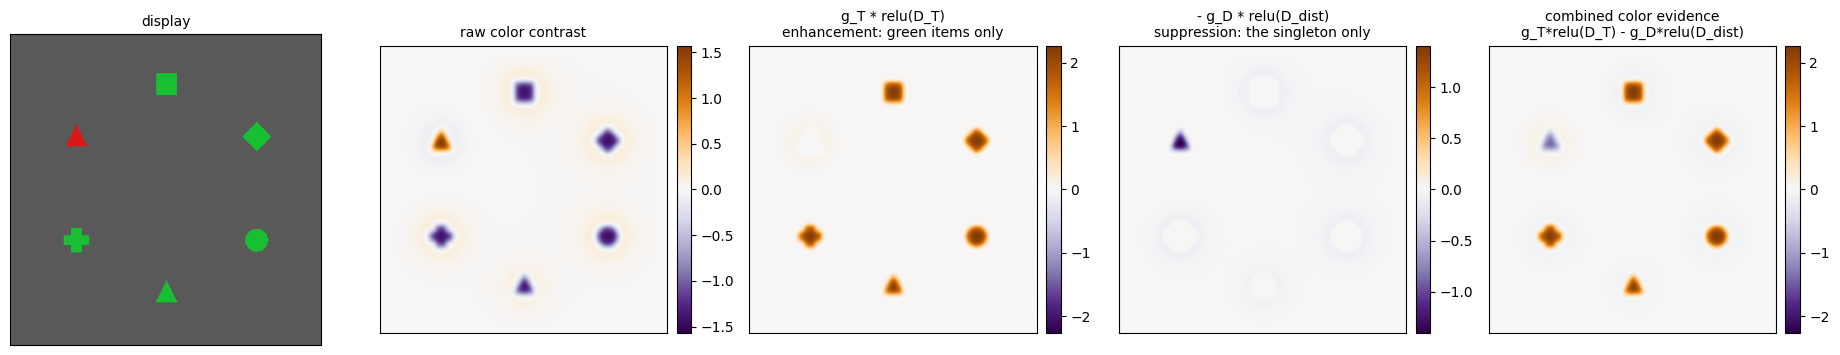

In [4]:
gT_demo, gD_demo, gF_demo = 1.5, 0.8, 1.2      # placeholder gains

TARG, SING = 1, 4
items = [dict(x=pos[j][0], y=pos[j][1],
              color="red" if j == SING else "green",
              shape=shape_for(j + 1, TARG + 1)) for j in range(6)]
img = render(items)
maps = opponency_contrast(img)
u = template_axis("green")            # the goal color, as a direction
perp = (-u[1], u[0])

goal_map = u[0]*maps["RG"] + u[1]*maps["BY"]          # D_T: + green, - red
off_map = perp[0]*maps["RG"] + perp[1]*maps["BY"]
uS = template_axis("red")
cphi, sphi = u[0]*uS[0] + u[1]*uS[1], perp[0]*uS[0] + perp[1]*uS[1]
distractor_map = cphi*goal_map + sphi*off_map         # D_dist: + red
chanT = np.maximum(goal_map, 0)                       # relu(D_T)
chanD = np.maximum(distractor_map, 0)                 # relu(D_dist)
color_evidence = gT_demo*chanT - gD_demo*chanD          # combined

fig, axes = plt.subplots(1, 5, figsize=(18.5, 3.8))
axes[0].imshow(img, origin="lower"); axes[0].set_title("display", fontsize=10)
v = np.abs(maps["RG"]).max()
im1 = axes[1].imshow(maps["RG"], origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[1].set_title("raw color contrast", fontsize=10)
v2 = (gT_demo*chanT).max()
im2 = axes[2].imshow(gT_demo*chanT, origin="lower", cmap="PuOr_r",
                     vmin=-v2, vmax=v2)
axes[2].set_title("g_T * relu(D_T)\nenhancement: green items only",
                  fontsize=10)
v3 = (gD_demo*chanD).max()
im3 = axes[3].imshow(-gD_demo*chanD, origin="lower", cmap="PuOr_r",
                     vmin=-v3, vmax=v3)
axes[3].set_title("- g_D * relu(D_dist)\nsuppression: the singleton only",
                  fontsize=10)
v = np.abs(color_evidence).max()
im4 = axes[4].imshow(color_evidence, origin="lower", cmap="PuOr_r",
                     vmin=-v, vmax=v)
axes[4].set_title("combined color evidence\ng_T*relu(D_T) - g_D*relu(D_dist)",
                  fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in zip(axes[1:], [im1, im2, im3, im4]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

Read the color pathway left to right: the raw map knows only
that colored things sit on a gray background; the `g_T` panel contains
ONLY the green items (turning `g_T` up rescales this panel alone); the
`g_D` panel contains ONLY the singleton's hole (turning `g_D` up deepens
it alone); their sum is the combined color evidence — green items
up, singleton below zero, each side under its own knob.

**Adding shape.** The shape map is color-blind: how circle-like
each location's contour is, computed from the pixels by template
matching (normalized cross-correlation with a circle, minus the
best competing shape's match). Its gain is `g_F`: higher
`g_F` raises the circle-matching location — the target — over
every other item, green or red. The **goal-modified salience map**
is the pixel-wise sum:

    g_T * relu(D_T) - g_D * relu(D_dist) + g_F * shape

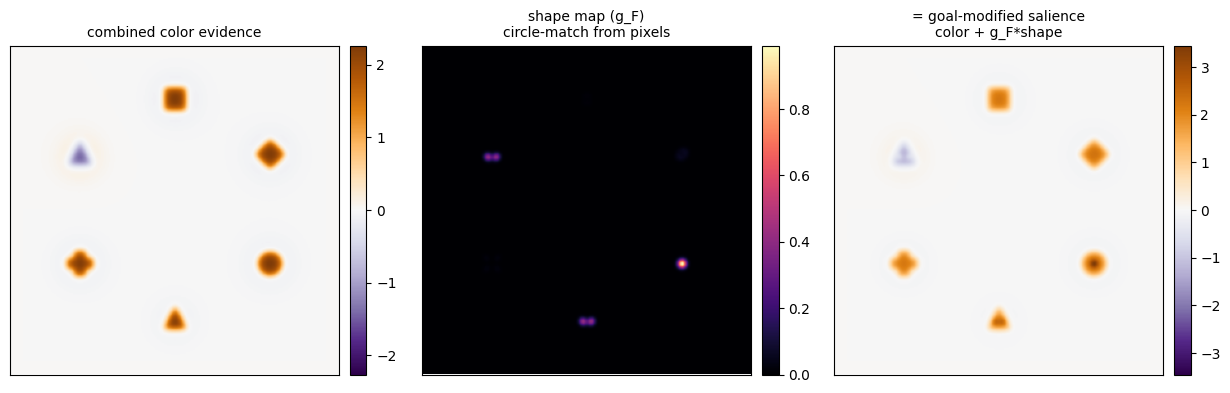

In [5]:
smap = shape_match_map(render(items, scale=2))
smap = smap[::2, ::2] / max(smap.max(), 1e-9)         # display scale
salience = color_evidence + gF_demo * smap

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
v = np.abs(color_evidence).max()
im0 = axes[0].imshow(color_evidence, origin="lower", cmap="PuOr_r",
                     vmin=-v, vmax=v)
axes[0].set_title("combined color evidence", fontsize=10)
im1 = axes[1].imshow(smap, origin="lower", cmap="magma")
axes[1].set_title("shape map (g_F)\ncircle-match from pixels",
                  fontsize=10)
v = np.abs(salience).max()
im2 = axes[2].imshow(salience, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[2].set_title("= goal-modified salience\ncolor + g_F*shape",
                  fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in zip(axes, [im0, im1, im2]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

In the final map the target is doubly bright (right color AND
right shape), the plain green items carry color evidence only, and
the red singleton is a signed hole whose depth is `g_D`'s alone to
set. Signed maps: orange = positive, purple = negative, scales
symmetric around zero; the shape map is non-negative.

**Two things you may notice in the shape map:**

- **The bright spot is smaller than the circle itself.** That is
  what a template-MATCH map looks like, not a smoothing artifact.
  Each pixel answers "is a circle centered HERE?" — not "is this
  pixel part of a circle?" The answer is a clear yes only when the
  template sits right on the item's center; shift it a few pixels
  and the match drops. So the map shows a narrow alignment peak at
  the circle's center rather than a filled disk — and that is all
  the model needs, because shape evidence is read out exactly at
  the item centers.
- **Faint dots at some non-circle items (the triangles).** The map
  scores each spot as "circle match MINUS the best other shape's
  match," so at a triangle's center the triangle template wins and
  the score is zero. But just OFF a triangle's center the
  comparison tilts the other way: a circle is round, so its
  template forgives a small misalignment, while the triangle
  template loses its match quickly. Those thin rims of
  "circle-beats-triangle-by-a-sliver" survive as faint dots. They
  are the honest fingerprint of computing shape from pixels —
  about 6x weaker than the real circle's peak, so the model is
  never actually fooled. (Color plays no role: the image is reduced
  to black-and-white before shape matching, so the red singleton's
  stronger color cannot masquerade as shape evidence.)

## 4. The attention window

The window is an **ego-anchored sigmoid of distance from the eyes**:

    window(d) = sigmoid( k * (r0 - d) )

Here `d` is the distance between the current fixation (where the
eyes are) and a location on the screen — for the 2-D map, every
pixel gets its own `d`; for the item readout, `d` is the
fixation-to-item distance. Distances are in display units where
the ring items sit at `d = 0.5` from the screen center.

Two parameters shape the window: `r0` is its REACH (the distance
at which weight has fallen to one half — a location closer than
`r0` gets most of the weight, one farther gets little) and `k` its
STEEPNESS (how abruptly weight falls off around `r0`). Left: the 1-D function. Middle: the same function
painted over the display as a 2-D field centered on fixation.
Right: the combination — the window multiplies the goal-modified
salience map, pixel by pixel:

    priority(x) = window(x) * salience(x)

To choose between items, the priority map is AVERAGED over each
item's sector — one number per item (an average, so the number does
not depend on how big the sector is). (The trained pipeline computes
the same product along rays toward each item instead of every
pixel — faster, same math.)

**Why changing `r0` on its own can look like nothing happened:**
from central fixation every ring item sits at the same distance
(d = 0.5), so the window multiplies the whole visible map by ONE
number — and a panel normalized to its own maximum cancels a
uniform rescaling. To make the window's effect visible, the last
two panels show the SAME salience map under two different windows —
a wide one and a narrow one — drawn on the SAME color scale: the
narrow window dims the entire map uniformly. That uniform dimming
is the §1 note made visible: within this model's first-saccade
scope the window acts as a shared gain on equidistant items, which
is exactly why the data constrain its parameters only weakly and
it is kept on theoretical definition.

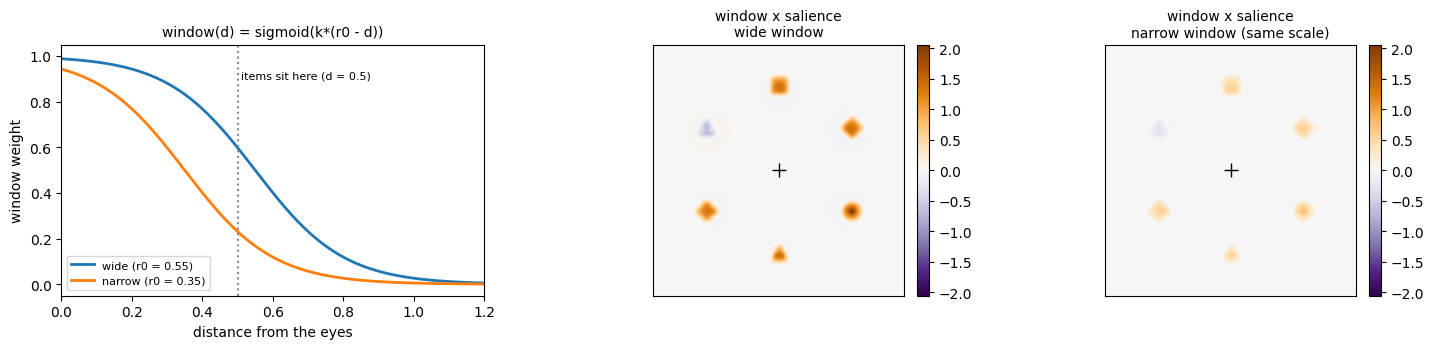

In [6]:
k_demo, r0_demo = 8.0, 0.55               # a WIDE window
r0_narrow = 0.35                            # and a NARROW one

d = np.linspace(0, 1.2, 200)
cx = cy = IMG / 2
px_per_unit = IMG / 1.5
yy, xx = np.mgrid[0:IMG, 0:IMG]
dist_map = np.hypot(xx - cx, yy - cy) / px_per_unit
window_map = sigmoid(k_demo * (r0_demo - dist_map))     # the wide window
priority_wide = window_map * salience
priority_narrow = sigmoid(k_demo * (r0_narrow - dist_map)) * salience

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
axes[0].plot(d, sigmoid(k_demo * (r0_demo - d)), lw=2,
             label=f"wide (r0 = {r0_demo})")
axes[0].plot(d, sigmoid(k_demo * (r0_narrow - d)), lw=2,
             label=f"narrow (r0 = {r0_narrow})")
axes[0].axvline(0.5, color="#888888", ls=":")
axes[0].text(0.51, 0.9, "items sit here (d = 0.5)", fontsize=8,
             clip_on=True)
axes[0].set_xlim(0, 1.2); axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlabel("distance from the eyes")
axes[0].set_ylabel("window weight")
axes[0].set_title("window(d) = sigmoid(k*(r0 - d))", fontsize=10)
axes[0].legend(fontsize=8)

v = np.abs(priority_wide).max()             # ONE shared color scale
for ax, m, ttl in [(axes[1], priority_wide,
                    "window x salience\nwide window"),
                   (axes[2], priority_narrow,
                    "window x salience\nnarrow window (same scale)")]:
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(cx, cy, "k+", ms=10)
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 5. Location-based selection history

The model remembers WHERE things have been — not what they looked
like. Two memories, one number per screen location, updated after
every trial as **leaky accumulators**:

    h = (1 - eta) * h              # everything leaks a little
    h[location] += eta             # this trial's location gets a boost

`h_T` tracks target locations (update speed `eta_T`), `h_D` tracks
distractor locations (`eta_D`).

**Units:** each location's `h` is a recency-weighted occupancy — the
leaky average of "was the item here this trial?" (1 or 0) — so every
entry lies between 0 and 1 on its own. These are NOT probabilities
and nothing normalizes them across locations. (For `h_T` the six
entries do happen to sum to ~1 at steady state, because exactly one
target appears per trial: the update adds `eta` to one slot while
shrinking all slots by `1 - eta`. For `h_D` the sum settles near
the singleton-present rate instead, since absent trials add
nothing.) A large `eta` means a fast, forgetful
memory dominated by the last trial; a small `eta` means a slow one
that averages many trials. Their gains in the priority map are
`beta_T` (positive: past target locations PULL the eyes) and `beta_D`
(negative: past distractor locations PUSH the eyes away).

In the model the history term is computed PER ITEM — the window is
evaluated once at each item's distance and multiplies that item's
scalar history value:

    history_prior_i = window(dist_i) * (beta_T*hT_i + beta_D*hD_i)

Below, in three steps kept deliberately separate:

1. **the accumulator** (left) — one location's `h` across simulated
   trials, for a fast and a slow `eta`; each tick marks a trial
   where the item landed on that location;
2. **the prior itself** (middle) — computed location by location,
   exactly as in the model: six numbers, one per item, each equal
   to `window(dist_i) * (beta_T*hT_i + beta_D*hD_i)`. THIS is the
   spatial prior; nothing more;
3. **a visualization of those six numbers** (right) — each item's
   value painted as a blob at its screen location, purely to make
   the map readable. The painting adds no content: blob color =
   bar height in the middle panel.

history prior per item: [ 0.068  1.041  0.068 -0.141  0.068  0.142]


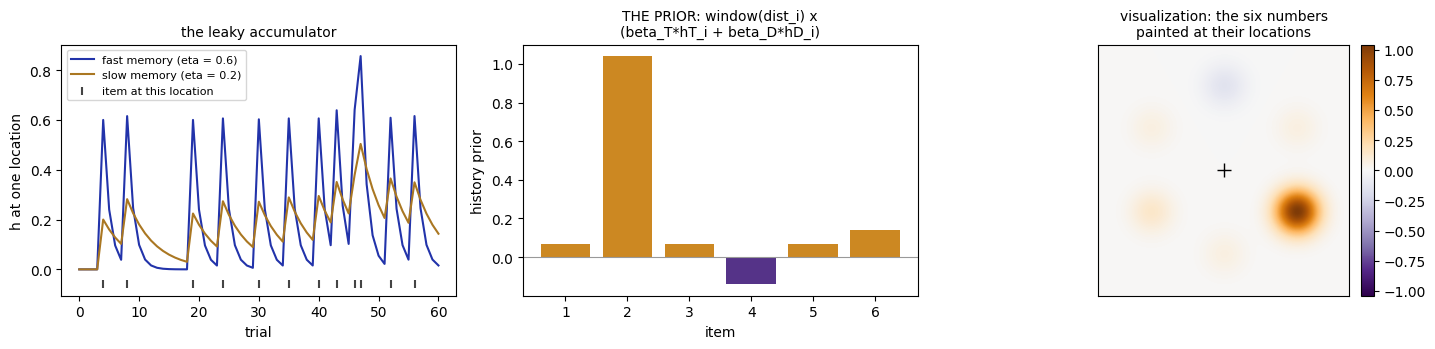

In [7]:
rng = np.random.default_rng(4)
hits = rng.random(60) < 0.3                 # trials landing on this location
h_fast = np.zeros(61); h_slow = np.zeros(61)
for t in range(60):
    h_fast[t+1] = 0.4*h_fast[t] + 0.6*hits[t]     # eta = 0.6
    h_slow[t+1] = 0.8*h_slow[t] + 0.2*hits[t]     # eta = 0.2

def paint_slots(vals, sig=0.09):
    m = np.zeros((IMG, IMG))
    for j in range(6):
        px, py = (pos[j][0]+0.75)/1.5*IMG, (pos[j][1]+0.75)/1.5*IMG
        m += vals[j]*np.exp(-((xx-px)**2 + (yy-py)**2)
                            / (2*(sig*px_per_unit)**2))
    return m

# recency-weighted occupancies (see Units above): h_T sums to ~1
# (one target per trial), h_D to ~the singleton-present rate
hT_demo = np.array([0.05, 0.70, 0.05, 0.05, 0.05, 0.10])  # target often at slot 2
hD_demo = np.array([0.02, 0.02, 0.02, 0.60, 0.02, 0.02])  # distractor often at slot 4
betaT_demo, betaD_demo = 2.5, -0.6                    # placeholder gains

# ---- THE PRIOR, location by location (the model's actual quantity) ----
history_prior = np.zeros(6)
for i in range(6):
    dist_i = 0.5                                  # all ring items sit here
    win_i = sigmoid(k_demo * (r0_demo - dist_i))  # window AT item i
    history_prior[i] = win_i * (betaT_demo*hT_demo[i]
                                + betaD_demo*hD_demo[i])
print("history prior per item:", history_prior.round(3))

# ---- VISUALIZATION ONLY: paint each item's number at its location ----
prior_img = paint_slots(history_prior)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
axes[0].plot(h_fast, color="#2233aa", label="fast memory (eta = 0.6)")
axes[0].plot(h_slow, color="#aa7722", label="slow memory (eta = 0.2)")
axes[0].scatter(np.where(hits)[0]+1, np.full(hits.sum(), -0.06),
                marker="|", color="#444444", label="item at this location")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("h at one location")
axes[0].set_title("the leaky accumulator", fontsize=10)
axes[0].legend(fontsize=8)
cols = ["#cc8822" if v_ >= 0 else "#553388" for v_ in history_prior]
axes[1].bar(range(1, 7), history_prior, color=cols)
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_xlabel("item"); axes[1].set_ylabel("history prior")
axes[1].set_title("THE PRIOR: window(dist_i) x\n"
                  "(beta_T*hT_i + beta_D*hD_i)", fontsize=10)
v = np.abs(prior_img).max()
im_p = axes[2].imshow(prior_img, origin="lower", cmap="PuOr_r",
                      vmin=-v, vmax=v)
axes[2].plot(cx, cy, "k+", ms=10)
axes[2].set_title("visualization: the six numbers\n"
                  "painted at their locations", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im_p, ax=axes[2], fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 6. The final model: `priority_map()`

Everything above, assembled into one function that takes the **raw
image**. Nothing in it is new — each block is a copy of code you
have already seen, labeled by its section:

1. **perception** (no learned weights): the Sec. 3 color maps and
   rectified channels, the Sec. 3 shape map read at each item, and
   each item's distance from fixation;
2. **combination** (the nine learned weights): the Sec. 3
   goal-modified salience map (color gains + g_F*shape, pixel by
   pixel), the Sec. 4 window multiplication and per-item sector
   average, and the Sec. 5 history prior. Nothing else.

`softmax(priority_map(...))` is the predicted probability of the
first saccade landing on each item.

In [8]:
def priority_map(img, h_T, h_D, w,
                 target_color="green", distractor_color="red"):
    '''Raw image + location histories + weights -> one priority per item.

    img       -- the display, as pixels [256, 256, 3]
    h_T, h_D  -- target / distractor location histories (Sec. 5)
    w         -- dict of the nine learned weights
    softmax of the return value predicts the first saccade.
    '''
    W = {k_: float(v_) for k_, v_ in w.items()}

    # ---------- perception: pixels -> evidence (no learned weights) ----------
    # the Sec. 3 color pathway, line for line
    cmaps = opponency_contrast(img)
    u_ = template_axis(target_color); perp_ = (-u_[1], u_[0])
    gmap = u_[0]*cmaps["RG"] + u_[1]*cmaps["BY"]
    omap = perp_[0]*cmaps["RG"] + perp_[1]*cmaps["BY"]
    uS_ = template_axis(distractor_color)
    cph_ = u_[0]*uS_[0] + u_[1]*uS_[1]
    sph_ = perp_[0]*uS_[0] + perp_[1]*uS_[1]
    dmap = cph_*gmap + sph_*omap
    chT = np.maximum(gmap, 0)                  # relu(D_T), Sec. 3
    chD = np.maximum(dmap, 0)                  # relu(D_dist), Sec. 3
    # the Sec. 3 shape map
    sm = shape_match_map(img); sm = sm / max(sm.max(), 1e-9)
    # geometry: fixation at the center
    dist_i = np.array([np.hypot(pos[j][0], pos[j][1]) for j in range(6)])

    # ---------- combination: the nine learned weights ----------
    salience_map = (W["g_T"]*chT - W["g_D"]*chD
                    + W["g_F"]*sm)                       # Sec. 3, pixel by pixel
    yy_, xx_ = np.mgrid[0:IMG, 0:IMG]
    d_px = np.hypot(xx_ - IMG/2, yy_ - IMG/2) / (IMG/1.5)
    window_map_ = sigmoid(W["k"] * (W["r0"] - d_px))     # Sec. 4
    priority_px = window_map_ * salience_map             # Sec. 4, pixel by pixel
    ang = np.arctan2(yy_ - IMG/2, xx_ - IMG/2)
    stimulus_evidence = np.zeros(6)
    for j_ in range(6):                                  # Sec. 4 sector average
        aj = np.arctan2(pos[j_][1], pos[j_][0])
        in_sector = np.abs((ang - aj + np.pi) % (2*np.pi) - np.pi) < np.deg2rad(30)
        stimulus_evidence[j_] = priority_px[in_sector].mean()
    window_at_item = sigmoid(W["k"] * (W["r0"] - dist_i))
    history_prior = window_at_item * (W["beta_T"]*h_T.numpy()[0]
                                      + W["beta_D"]*h_D.numpy()[0])  # Sec. 5
    return torch.tensor(stimulus_evidence + history_prior).float()[None]

print("the model. softmax(priority_map(img, ...)) is the prediction.")

the model. softmax(priority_map(img, ...)) is the prediction.


(With these placeholder gains the history term dominates the
absolute numbers — the trained gains of Sec. 7 set the real
balance, on evidence the pipeline standardizes to unit scale.)

### One worked example, raw image to prediction

Inputs: the Sec. 3 display (pixels), the Sec. 5 histories, and
placeholder weights. Output: six priorities, softmaxed into six
probabilities — the prediction. One predicted saccade is one random
draw from those probabilities.

priority per item: [ 0.08  1.06  0.09 -0.11  0.06  0.16]
P(first saccade):  [13.2 35.2 13.3 10.9 13.  14.3] %
most likely saccade: item 2 (the target; one PREDICTED saccade = one draw from these)


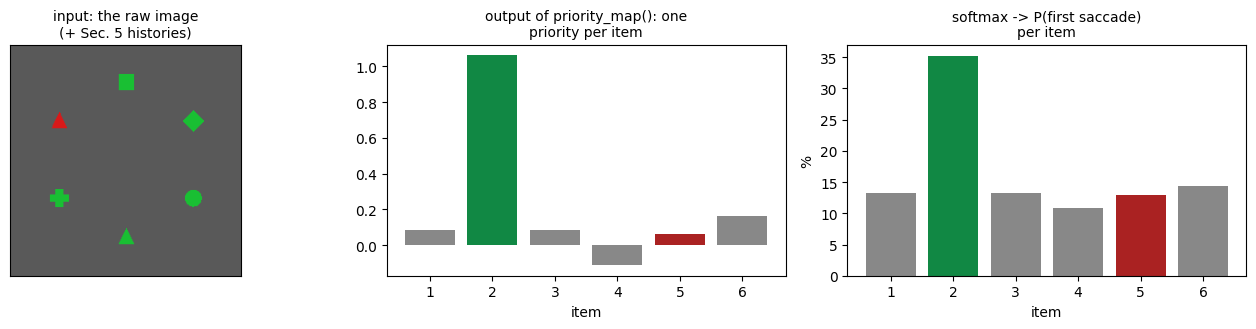

In [9]:
w_demo = dict(g_T=gT_demo, g_D=gD_demo, g_F=gF_demo,
              k=k_demo, r0=r0_demo,
              beta_T=betaT_demo, beta_D=betaD_demo)
h_T_ex = torch.tensor(hT_demo).float()[None]      # Sec. 5 histories
h_D_ex = torch.tensor(hD_demo).float()[None]

F_ex = priority_map(img, h_T_ex, h_D_ex, w_demo)  # RAW IMAGE in -> [1, 6] out
p_ex = torch.softmax(F_ex, 1)                     # probabilities

print("priority per item:", F_ex[0].numpy().round(2))
print("P(first saccade): ", (p_ex[0].numpy() * 100).round(1), "%")
print("most likely saccade: item", int(F_ex[0].argmax()) + 1,
      "(the target; one PREDICTED saccade = one draw from these)")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
axes[0].imshow(img, origin="lower")
axes[0].set_title("input: the raw image\n(+ Sec. 5 histories)", fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])
cols = ["#888888"] * 6
cols[TARG], cols[SING] = "#118844", "#aa2222"
axes[1].bar(range(1, 7), F_ex[0].numpy(), color=cols)
axes[1].set_title("output of priority_map(): one\npriority per item",
                  fontsize=10)
axes[1].set_xlabel("item")
axes[2].bar(range(1, 7), p_ex[0].numpy() * 100, color=cols)
axes[2].set_title("softmax -> P(first saccade)\nper item", fontsize=10)
axes[2].set_xlabel("item"); axes[2].set_ylabel("%")
plt.tight_layout()
plt.show()

## 7. Train on the actual data

The dataset holds every first saccade from 333 people: which item
they looked at first, the display they saw, and the full trial order
(needed to rebuild each person's memories).

**What is excluded, from both training and test data** (the
exclusions happen at the pooling step, `pool_data.py`):

- trials with **motion/dynamic or onset singletons** (abrupt onsets,
  singleton onsets, motion singletons) — only static color-singleton
  and singleton-absent trials are analyzed, as in the source paper;
- **Stilwell's low-salience singleton trials** — the canonical
  reconstruction (a salient red-on-green singleton) only matches the
  high-salience displays; the low-salience condition is held
  entirely outside the model and used as an out-of-sample test in §9.

We hold out 20% of the *people* — the model never sees them during
training — and fit by maximum likelihood: replay everyone's trials,
score the probability the model gives to each real eye movement, and
nudge all nine numbers by gradient descent. The memory speeds are
learned too, so the memories are rebuilt inside the training loop.

One practical note: the perception half of `priority_map()` has no
learned weights, so training does not re-run it on pixels at every
step. Instead `build_contexts.py` computed, once per display, the
same color evidence sampled along 24-bin RAYS toward each item
(`D_T`, `D_dist`; the faster equivalent of the Sec. 4 sector
average, as flagged there) plus the per-item shape values — and
training looks them up. `combine_evidence()` below applies the same
combination equation as `priority_map()`, taking that cached
evidence.

In [10]:
import data

sacc = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False)  # a row per first saccade
ev = pd.read_csv("dataset/events.csv", low_memory=False)  # a row per trial (histories)
ctx = np.load("dataset/contexts_v21.npz")  # precomputed ray profiles + shape per display
sacc, tt = data.build_tensors(sacc, ev)    # a few minutes: aligns everything into tensors

from model import color_angles

# look up each saccade's display in the precomputed maps (same objects as Sec. 6)
cid = torch.tensor(sacc.ctx.values.astype(int))  # which display this saccade saw
P = torch.tensor(ctx["P"])[cid]                  # its ray profiles [N, 6, 24, 3]
FORM = torch.tensor(ctx["FORM"])[cid]            # its shape evidence [N, 6]
cphi, sphi = color_angles(sacc)   # each study's distractor-color axis vs target axis
D_T = P[..., 0]                                          # target-color profiles
D_dist = (cphi[:, None, None] * P[..., 0]                # rotate onto the
          + sphi[:, None, None] * P[..., 1])             # distractor axis
radii = torch.linspace(0.09, 1.1, P.shape[2])            # ray distance bins
N = len(sacc)
dist = torch.ones(N, 6)                   # fixation-to-item distances (d1..d6)
for j in range(1, 7):
    ok = sacc[f"d{j}"].notna().values
    dist[ok, j-1] = torch.tensor(sacc.loc[ok, f"d{j}"].values,
                                 dtype=torch.float32)

n_subj = tt["eT"].shape[0]
rng = np.random.default_rng(0)
test_subj = torch.zeros(n_subj, dtype=torch.bool)
test_subj[rng.choice(n_subj, n_subj // 5, replace=False)] = True
test = test_subj[tt["si"]]
train = ~test
print(f"{N} saccades; {int((~test_subj).sum())} people to train on, "
      f"{int(test_subj.sum())} held out")

114232 saccades; 267 people to train on, 66 held out


epoch 0: loss 1.6885


epoch 25: loss 1.4597


epoch 50: loss 1.4271


epoch 75: loss 1.4221


epoch 100: loss 1.4191


epoch 125: loss 1.4185


epoch 150: loss 1.4185


epoch 175: loss 1.4185


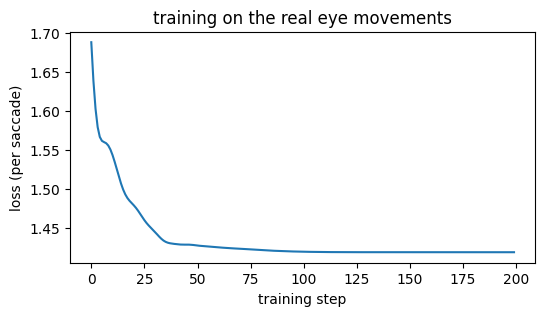

In [11]:
def combine_evidence(D_T, D_dist, shape, dist, h_T, h_D, w, radii):
    # the same combination equation as priority_map() (Sec. 6),
    # applied to the precomputed ray-sampled evidence
    window_along_rays = torch.sigmoid(w["k"] * (w["r0"] - radii))
    color_drive = (w["g_T"] * torch.relu(D_T)
                   - w["g_D"] * torch.relu(D_dist))
    color_evidence = (color_drive * window_along_rays).sum(-1)
    window_at_item = torch.sigmoid(w["k"] * (w["r0"] - dist))
    history_prior = window_at_item * (w["beta_T"]*h_T + w["beta_D"]*h_D)
    return color_evidence + window_at_item * w["g_F"]*shape + history_prior

def build_memories(eta_T, eta_D):
    # replay every subject's trials in order; return memory AS OF each trial
    S_, T_, _ = tt["eT"].shape
    hT = torch.zeros(S_, 6); hD = torch.zeros(S_, 6)
    outT, outD = [], []
    for t in range(T_):
        outT.append(hT); outD.append(hD)
        hT = (1 - eta_T) * hT + eta_T * tt["eT"][:, t]
        hD = (1 - eta_D) * hD + eta_D * tt["eD"][:, t]
    return torch.stack(outT, 1), torch.stack(outD, 1)

w = {name: torch.tensor(v, requires_grad=True) for name, v in
     [("g_T", 0.5), ("g_D", 0.3), ("g_F", 1.0),
      ("k", 2.0), ("r0", 0.5), ("beta_T", 0.5), ("beta_D", -0.1)]}
raw_eta = {n: torch.tensor(0.0, requires_grad=True) for n in ["T", "D"]}
optimizer = torch.optim.Adam(list(w.values()) + list(raw_eta.values()),
                             lr=0.05)

losses = []
for epoch in range(200):                       # ~10 minutes
    eta_T = torch.sigmoid(raw_eta["T"]); eta_D = torch.sigmoid(raw_eta["D"])
    memT, memD = build_memories(eta_T, eta_D)
    hT = memT[tt["si"], tt["ti"]]; hD = memD[tt["si"], tt["ti"]]
    F = combine_evidence(D_T, D_dist, FORM, dist, hT, hD, w, radii)  # priority per item
    F = F.masked_fill(~tt["valid"], -1e9)     # empty slots can never be chosen
    logp = torch.log_softmax(F, 1).gather(     # softmax -> P(item); keep the
        1, tt["choice"][:, None]).squeeze(1)   # probability of the REAL choice
    loss = -logp[train].mean()                 # maximize likelihood of real saccades
    optimizer.zero_grad(); loss.backward(); optimizer.step()  # nudge the 9 weights
    losses.append(loss.item())
    if epoch % 25 == 0:
        print(f"epoch {epoch}: loss {loss.item():.4f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("training step"); plt.ylabel("loss (per saccade)")
plt.title("training on the real eye movements")
plt.show()

In [12]:
learned = {k: v.item() for k, v in w.items()}
learned["eta_T"] = torch.sigmoid(raw_eta["T"]).item()
learned["eta_D"] = torch.sigmoid(raw_eta["D"]).item()
for name, meaning in [
        ("g_T", "enhance the target color"),
        ("g_D", "suppress the distractor color"),
        ("g_F", "goal shape attracts"),
        ("k", "window steepness"), ("r0", "window reach"),
        ("beta_T", "pull toward past target locations"),
        ("beta_D", "push from past distractor locations"),
        ("eta_T", "target memory speed (fast)"),
        ("eta_D", "distractor memory speed (slow)")]:
    print(f"{name:8} = {learned[name]:+7.3f}   {meaning}")
print("\nnote: within a two-color display only the a/b COMBINATION is")
print("identified, so their individual signs should not be interpreted.")

g_T      =  +0.006   enhance the target color
g_D      =  +0.108   suppress the distractor color
g_F      =  +0.709   goal shape attracts
k        =  +2.165   window steepness
r0       =  +0.944   window reach
beta_T   =  +2.921   pull toward past target locations
beta_D   =  -0.583   push from past distractor locations
eta_T    =  +0.597   target memory speed (fast)
eta_D    =  +0.177   distractor memory speed (slow)

note: within a two-color display only the a/b COMBINATION is
identified, so their individual signs should not be interpreted.


## 8. Evaluation: how good is it? (held-out people only)

We score the model ONLY on the people it never saw. Three measures,
each with its recipe:

- **Mean probability on the true choice.** For every held-out
  saccade, read off the probability the model assigned to the item
  the person actually looked at, then average the *log* of those
  probabilities and exponentiate (the geometric mean — the standard
  likelihood-based average). Chance is 1/(number of items on
  screen), about 18% across the pooled set sizes.
- **Top-1 accuracy.** How often the person's actual choice was the
  model's single highest-probability item. Chance ~18% again.
- **Pseudo-R-squared.** `1 - NLL_model / NLL_chance`, where NLL is
  the mean negative log-likelihood per saccade and the chance model
  spreads probability evenly over the items. 0 means no better than
  guessing, 1 means perfect prediction; for models of human choices,
  0.2-0.4 counts as excellent (human choices are intrinsically
  variable — even the same person, same display, same history does
  not always look at the same item, so 1.0 is unreachable in
  principle).

In [13]:
with torch.no_grad():
    eta_T = torch.sigmoid(raw_eta["T"]); eta_D = torch.sigmoid(raw_eta["D"])
    memT, memD = build_memories(eta_T, eta_D)
    hT = memT[tt["si"], tt["ti"]]; hD = memD[tt["si"], tt["ti"]]
    F = combine_evidence(D_T, D_dist, FORM, dist, hT, hD, w, radii)
    F = F.masked_fill(~tt["valid"], -1e9)
    prob = torch.softmax(F, 1)
    p_true = prob.gather(1, tt["choice"][:, None]).squeeze(1)

nll = -p_true[test].log().mean()
chance = torch.log(tt["valid"].sum(1).float())[test].mean()
print(f"held-out saccades: {int(test.sum())}")
print(f"mean probability on the true choice: "
      f"{p_true[test].log().mean().exp()*100:.1f}%  "
      f"(chance {torch.exp(-chance)*100:.1f}%)")
print(f"top-1 accuracy: "
      f"{(prob.argmax(1) == tt['choice'])[test].float().mean()*100:.1f}%")
print(f"pseudo-R-squared vs chance: {1 - nll/chance:.3f}")

held-out saccades: 23216
mean probability on the true choice: 25.3%  (chance 17.4%)
top-1 accuracy: 45.7%
pseudo-R-squared vs chance: 0.213


**Interpretation.** The model roughly halves the uncertainty about
where a stranger's first saccade will land: ~24% geometric-mean
probability on the true choice against 18% chance, the right item as
its top guess almost half the time against ~18% chance, and a
pseudo-R-squared around 0.22 — squarely in the "excellent for human
choice data" band. For calibration: memorization benchmarks built
from the training people (a lookup table of choice frequencies per
display, even per PERSON) score WORSE than this model, because the
graded history traces carry information no frequency table can
(see RESULTS.md, "Oracle benchmarks").

## 9. Does it behave like people? Three signature patterns

Numbers are one thing; the literature's signature patterns are the
real test. Everything below uses held-out people only, and nothing
was fitted to these specific patterns — they come out of the one
trained equation.

**9a. Oculomotor suppression.** First saccades go to the salient red
distractor LESS often than to an average plain item — the
below-baseline suppression effect this dataset exists to measure.

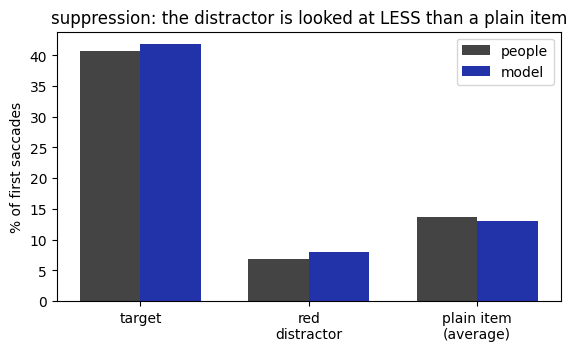

In [14]:
first = torch.tensor((sacc.saccindex == 1).values)  # all True: the scope
sing_present = torch.tensor((sacc.singLoc > 0).values)
rows = torch.arange(N)
isT = torch.zeros(N, 6); isT[rows, torch.tensor(sacc.targLoc.values) - 1] = 1
isS = torch.zeros(N, 6)
sp = torch.tensor(sacc.singLoc.values)
isS[rows[sp > 0], sp[sp > 0] - 1] = 1
chose = torch.zeros(N, 6); chose[rows, tt["choice"]] = 1

m = test & first & sing_present
ot = (chose[m] * isT[m]).sum() / m.sum() * 100
os_ = (chose[m] * isS[m]).sum() / m.sum() * 100
mt = (prob[m] * isT[m]).sum() / m.sum() * 100
ms = (prob[m] * isS[m]).sum() / m.sum() * 100
n_plain = (tt["valid"][m].sum(1).float() - 2).clamp(min=1).mean()
ons = (100 - ot - os_) / n_plain
mns = (100 - mt - ms) / n_plain

x = np.arange(3); width = 0.36
plt.figure(figsize=(6.5, 3.5))
plt.bar(x - width/2, [ot, os_, ons], width, label="people", color="#444444")
plt.bar(x + width/2, [mt, ms, mns], width, label="model", color="#2233aa")
plt.xticks(x, ["target", "red\ndistractor", "plain item\n(average)"])
plt.ylabel("% of first saccades")
plt.title("suppression: the distractor is looked at LESS than a plain item")
plt.legend()
plt.show()

**9b. High- vs low-salience suppression (Stilwell).** Stilwell
(2023) varied how salient the singleton was (its color distance from
the other items) and found MORE suppression for MORE salient
singletons. This is a strong test here: the low-salience trials were
excluded from our dataset entirely (§7), so the model has never seen
them — colors or choices. We apply the trained weights, unchanged,
to Stilwell's displays rendered with their TRUE colors and compare
against the observed rates from the raw data.

(Light version: one target location with the five singleton
positions per color pair, no history terms — they balance across
conditions. The full battery is `stilwell_salience.py`. Observed
rates below come from the raw Stilwell file, which is not in the
repo — they are quoted from that battery.)

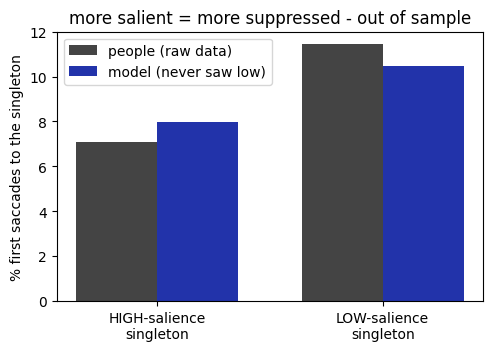

       obs   mod
high   7.1   8.0
low   11.4  10.5


In [15]:
# (salience condition, target color, singleton color, n, observed sing %)
PAIRS = [("high", "blue", "red",  2158,  7.0),
         ("low",  "blue", "teal", 2157, 11.0),
         ("high", "pink", "blue", 2160,  7.6),
         ("low",  "pink", "red",  2153,  9.3),
         ("high", "red",  "blue", 2159,  8.1),
         ("low",  "red",  "pink", 2160, 14.8),
         ("high", "teal", "pink", 1887,  5.4),
         ("low",  "teal", "blue", 1889, 10.5)]

# normalization constants of the canonical training build
def build_maps(tc, sc_, tl, sl):
    its = [dict(x=pos[j][0], y=pos[j][1],
                color=(sc_ if (j+1) == sl and sc_ != "none" else tc),
                shape=shape_for(j+1, tl)) for j in range(6)]
    im = render(its)
    Pw, _ = wedge_profiles(opponency_contrast(im), template_axis(tc),
                           (0.0, 0.0), 6)
    fmap = shape_match_map(render(its, scale=2))
    scpx = fmap.shape[0] // IMG
    to_px = lambda v: int(np.clip((v+0.75)/1.5*IMG*scpx, 0, IMG*scpx-1))
    Fv = np.array([fmap[to_px(pos[j][1]), to_px(pos[j][0])]
                   for j in range(6)])
    return Pw.astype(np.float32), Fv.astype(np.float32)

canon = [build_maps("green", "red", 1, sl) for sl in range(2, 7)]
canon += [build_maps("green", "none", 1, 0)]
P_STD = np.abs(np.stack([c[0] for c in canon])[..., :2]).std()
F_STD = np.stack([c[1] for c in canon]).std()

def model_sing_rate(tc, sc_):
    uT, uS2 = template_axis(tc), template_axis(sc_)
    cp = torch.tensor([uT[0]*uS2[0] + uT[1]*uS2[1]], dtype=torch.float32)
    sp2 = torch.tensor([-uT[1]*uS2[0] + uT[0]*uS2[1]], dtype=torch.float32)
    rates = []
    for sl in range(2, 7):                     # target slot 1, sing 2..6
        Pw, Fv = build_maps(tc, sc_, 1, sl)
        Pw = Pw.copy(); Pw[..., :2] /= P_STD; Fv = Fv / F_STD
        z = torch.zeros(1, 6)
        Fq = combine_evidence(torch.tensor(Pw)[None, ..., 0],
                   cp[:, None, None]*torch.tensor(Pw)[None, ..., 0]
                   + sp2[:, None, None]*torch.tensor(Pw)[None, ..., 1],
                   torch.tensor(Fv)[None], torch.full((1, 6), 0.5),
                   z, z, w, radii)
        rates.append(torch.softmax(Fq, 1)[0, sl-1].item()*100)
    return float(np.mean(rates))

rows_ = []
for sal, tc, sc_, n, obs in PAIRS:
    rows_.append((sal, n, obs, model_sing_rate(tc, sc_)))
res = pd.DataFrame(rows_, columns=["sal", "n", "obs", "mod"])
agg = pd.DataFrame({sal: dict(obs=(g["obs"]*g["n"]).sum()/g["n"].sum(),
                              mod=(g["mod"]*g["n"]).sum()/g["n"].sum())
                    for sal, g in res.groupby("sal")}).T

x = np.arange(2)
plt.figure(figsize=(5.5, 3.5))
plt.bar(x-0.18, agg.loc[["high", "low"], "obs"], 0.36,
        label="people (raw data)", color="#444444")
plt.bar(x+0.18, agg.loc[["high", "low"], "mod"], 0.36,
        label="model (never saw low)", color="#2233aa")
plt.xticks(x, ["HIGH-salience\nsingleton", "LOW-salience\nsingleton"])
plt.ylabel("% first saccades to the singleton")
plt.title("more salient = more suppressed - out of sample")
plt.legend()
plt.show()
print(agg.round(1))

The mechanism: a low-salience singleton's color sits NEAR the
target color in color space, so it picks up part of the `g_T`
enhancement and projects weakly onto its own distractor axis — it
largely escapes suppression. A high-salience singleton is
chromatically distant and takes the full signed `-b` hit. The
gradient falls out of the two color gains applied to colors the fit
never saw.

**9c. Target location priming.** Saccades to the target roughly
double when the target repeats its location; saccades to the
distractor drop when the distractor repeats its location. This is
the selection-history machinery (§5) doing its work.

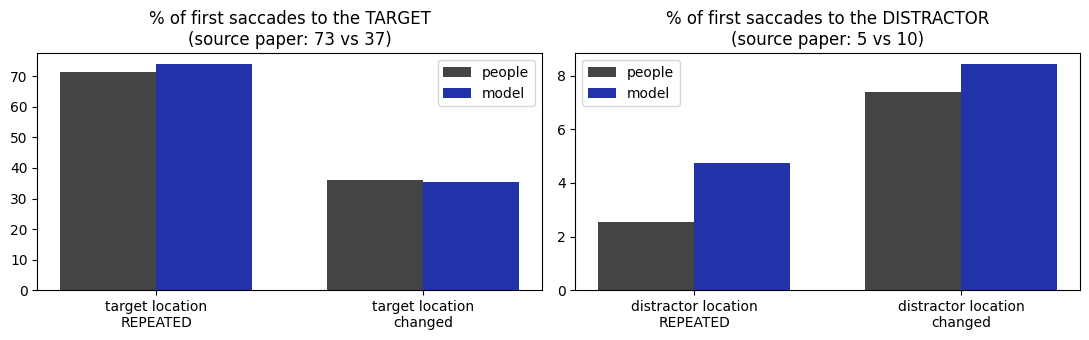

In [16]:
ev2 = ev.copy()
ev2["block"] = pd.to_numeric(ev2["block"], errors="coerce").fillna(0.0)
ev2["trial"] = pd.to_numeric(ev2["trial"], errors="coerce")
ev2["subj"] = ev2["subj"].astype(str)
ev2 = ev2.sort_values(["study", "subj", "block", "trial"])
ev2["prevT"] = ev2.groupby(["study", "subj"]).targLoc.shift(1)
ev2["prevS"] = ev2.groupby(["study", "subj"]).singLoc.shift(1)
key = ["study", "subj", "block", "trial"]
sacc2 = sacc.merge(ev2[key + ["prevT", "prevS"]], on=key, how="left")

def bar_pair(masks, pick, labels, title, paper):
    obs = [((chose[m_] * pick[m_]).sum() / m_.sum() * 100).item()
           for m_ in masks]
    mod = [((prob[m_] * pick[m_]).sum() / m_.sum() * 100).item()
           for m_ in masks]
    x = np.arange(2)
    plt.bar(x - 0.18, obs, 0.36, label="people", color="#444444")
    plt.bar(x + 0.18, mod, 0.36, label="model", color="#2233aa")
    plt.xticks(x, labels); plt.legend()
    plt.title(f"{title}\n{paper}")

plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
tr = test & first & torch.tensor(sacc2.prevT.values == sacc.targLoc.values)
tc_ = test & first & torch.tensor((sacc2.prevT.values != sacc.targLoc.values)
                                  & ~np.isnan(sacc2.prevT.values))
bar_pair([tr, tc_], isT,
         ["target location\nREPEATED", "target location\nchanged"],
         "% of first saccades to the TARGET", "(source paper: 73 vs 37)")
plt.subplot(1, 2, 2)
sr = test & first & sing_present & torch.tensor(
    (sacc2.prevS.values == sacc.singLoc.values) & (sacc2.prevS.values > 0))
sc2 = test & first & sing_present & torch.tensor(
    sacc2.prevS.values != sacc.singLoc.values)
bar_pair([sr, sc2], isS,
         ["distractor location\nREPEATED", "distractor location\nchanged"],
         "% of first saccades to the DISTRACTOR", "(source paper: 5 vs 10)")
plt.tight_layout()
plt.show()

## 10. The spatial prior, trial by trial

Section 5 showed the spatial prior with made-up history. Here it is
with the REAL trained memories of one held-out person: before each
display appears, the prior `window x (beta_T*h_T + beta_D*h_D)`
already tilts toward where their last target was. The green circle
marks the PREVIOUS trial's target location — watch the red bump
follow it from trial to trial. The bar on the right quantifies it
across all held-out trials: the prior at the previous target's
location versus the average other location.

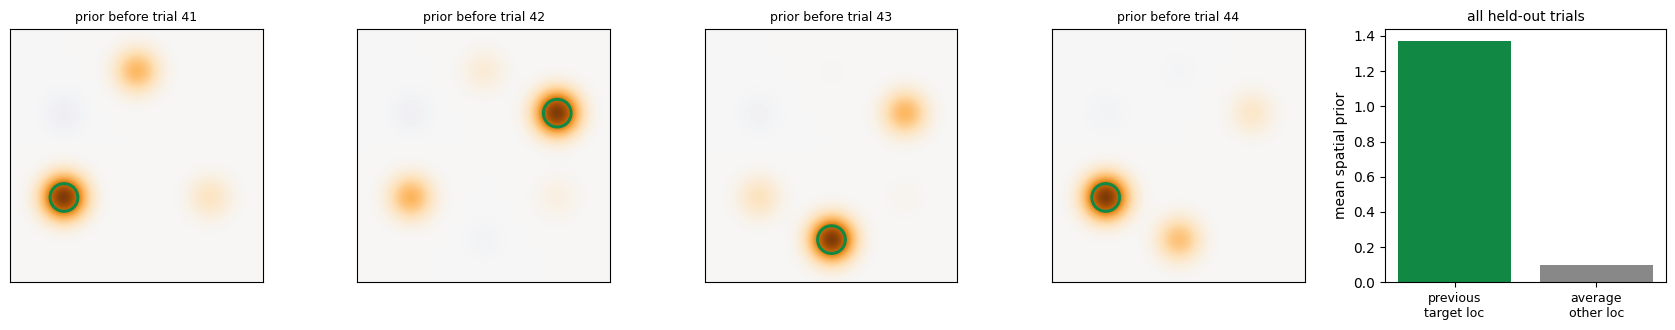

prior at previous target location: +1.369  vs other locations: +0.096


In [17]:
si_np = tt["si"].numpy(); ti_np = tt["ti"].numpy()
subj = int(np.unique(si_np[test.numpy()])[0])       # one held-out person
trials = np.sort(ti_np[(si_np == subj)])[40:44]     # four consecutive trials

with torch.no_grad():
    w_slot = torch.sigmoid(w["k"] * (w["r0"] - 0.5)).item()
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
    for ax, t in zip(axes[:4], trials):
        hT_t = memT[subj, t].numpy(); hD_t = memD[subj, t].numpy()
        # the prior, location by location (learned weights)...
        prior_t = w_slot * (learned["beta_T"]*hT_t
                            + learned["beta_D"]*hD_t)
        pm = paint_slots(prior_t)     # ...then painted, display only
        v = max(np.abs(pm).max(), 1e-9)
        ax.imshow(pm, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
        prev = int(tt["eT"][subj, t-1].argmax()) if t > 0 else None
        if prev is not None:
            px, py = (pos[prev][0]+0.75)/1.5*IMG, (pos[prev][1]+0.75)/1.5*IMG
            ax.add_patch(plt.Circle((px, py), 14, fill=False,
                                    ec="#118844", lw=2.2))
        ax.set_title(f"prior before trial {int(t)}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    # across all held-out trials: prior at prev-target loc vs elsewhere
    prior_slots = w_slot * (learned["beta_T"]*memT + learned["beta_D"]*memD)
    at_prev, at_other = [], []
    for s in np.unique(si_np[test.numpy()]):
        eT_s = tt["eT"][int(s)]
        T_ = int(ti_np[si_np == int(s)].max()) + 1
        for t in range(1, T_):
            prev = int(eT_s[t-1].argmax())
            if eT_s[t-1].sum() == 0:
                continue
            vals = prior_slots[int(s), t].numpy()
            at_prev.append(vals[prev])
            at_other.append(np.delete(vals, prev).mean())
    axes[4].bar([0, 1], [np.mean(at_prev), np.mean(at_other)],
                color=["#118844", "#888888"])
    axes[4].set_xticks([0, 1])
    axes[4].set_xticklabels(["previous\ntarget loc", "average\nother loc"],
                            fontsize=9)
    axes[4].set_ylabel("mean spatial prior")
    axes[4].set_title("all held-out trials", fontsize=10)
    plt.tight_layout()
    plt.show()
print(f"prior at previous target location: {np.mean(at_prev):+.3f}  "
      f"vs other locations: {np.mean(at_other):+.3f}")

## Recap

| The model receives | It returns |
| --- | --- |
| a picture, a goal, the trial history | a probability for every item |

We laid out the model structure (§1) and the displays (§2), followed
one display through the maps — raw color contrast, goal-modified
color (`g_T`, `g_D`), shape (`g_F`), and their sum, the goal-modified
salience map (§3) — gated it with the sigmoid attention window
(`k`, `r0`; §4), added the leaky-accumulator selection history
(`eta`, `beta`; §5), assembled the model into one function, priority_map, with a
worked raw-image-to-prediction example (§6), trained the nine numbers on the real
first eye movements with the motion-singleton and Stilwell
low-salience trials excluded (§7), evaluated on people the model
never saw with three explained metrics (§8), reproduced the three
signature patterns — suppression, salience-graded suppression out of
sample, and location priming (§9) — and watched the spatial prior
track the previous target location trial by trial (§10).

More: `RESULTS.md` (the full results record) and
`docs/priority_field_visual_search_model.md` (the theory).